# 1. Import CellRefiner and packages

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
import cellrefiner as cr

# 2. Load Data

Both spatial transcriptomics data and the scRNA-seq data for the lymph node can be found at https://github.com/romain-lopez/DestVI-reproducibility

In [ ]:
ad_sc = sc.read_h5ad('data/scRNA-LN-compressed.h5ad')
sc.pp.filter_cells(ad_sc,min_genes=3)
sc.pp.filter_genes(ad_sc,min_cells=3)
sc.pp.normalize_total(ad_sc, inplace=True)
sc.pp.log1p(ad_sc)
sc.tl.pca(ad_sc, svd_solver='arpack')
cluster_key_sc = 'cell_types'
# remove doublets and low quality
exclude_types = ['B doublets','B-CD4 T cell doublets','B-CD8 T cell doublets', 'B-macrophage doublets','Low quality B cells','T doublets']
ad_sc = ad_sc[~ad_sc.obs[cluster_key_sc].isin(exclude_types)]

ad_st = sc.read_h5ad('data/ST-LN-compressed.h5ad')
sc.pp.filter_cells(ad_st,min_genes=3)
sc.pp.filter_genes(ad_st,min_cells=3)
sc.pp.normalize_total(ad_st, inplace=True)
sc.pp.log1p(ad_st)
sc.tl.pca(ad_st, svd_solver='arpack')
cluster_key_st = 'leiden'
spatial_key = 'location'

print(ad_sc)
print(ad_st)

View of AnnData object with n_obs × n_vars = 14989 × 12805
    obs: 'n_genes', 'cell_types', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pred_cell_types', 'doublet_scores', 'doublet_predictions', 'MS', 'louvain_r0.5', 'louvain_r0.7', 'louvain_r1.0', 'leiden_r0.5', 'leiden_r0.7', 'leiden_r1.0', 'DC_A', 'DC_B', 'mono_1', 'mono_2', 'louvain_sub_0.1', 'louvain_sub_0.2', 'louvain_sub_0.3', 'louvain_sub', 'louvain_sub_1', 'louvain_sub_2', 'louvain_sub_3', 'SCANVI_pred_cell_types', 'SCVI_pred_cell_types', 'broad_cell_types'
    var: 'gene_ids-0', 'genome-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable'
    uns: 'batch_colors', 'leiden', 'leiden_r1.0_colors', 'louvain', 'louvain_r0.5_colors', 'louvain_r0.7_colors', 'louvain_r1.0_colors', 'louvain_sub_0.2_colors', 'louvain_sub_0.3_colors', 'louvain_sub_1_colors', 'neighbors', 'pred_cell_types_colors', 'umap', 'log1p', 'pca'
    obsm: 'X_scV

# 3. Run cellrefiner cell to spot mapping and spatial refinement 

Load the ligand-receptor database sourced from CellChat

In [5]:
db_lr = cr.pp.ligand_receptor_database(species='mouse')
adata_cr = cr.pp.spatial_mapping(ad_st,ad_sc,db_lr,cluster_key_sc = cluster_key_sc,spatial_key=spatial_key)
print(adata_cr)

/home/kxy/miniconda3/envs/cr_310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/kxy/miniconda3/envs/cr_310/lib/python3.10/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/home/kxy/miniconda3/envs/cr_310/lib/python3.10/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/home/kxy/miniconda3/envs/cr_310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


GPU acceleration available with CuPy
AnnData object with n_obs × n_vars = 5460 × 12805
    obs: 'n_genes', 'cell_types', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pred_cell_types', 'doublet_scores', 'doublet_predictions', 'MS', 'louvain_r0.5', 'louvain_r0.7', 'louvain_r1.0', 'leiden_r0.5', 'leiden_r0.7', 'leiden_r1.0', 'DC_A', 'DC_B', 'mono_1', 'mono_2', 'louvain_sub_0.1', 'louvain_sub_0.2', 'louvain_sub_0.3', 'louvain_sub', 'louvain_sub_1', 'louvain_sub_2', 'louvain_sub_3', 'SCANVI_pred_cell_types', 'SCVI_pred_cell_types', 'broad_cell_types'
    var: 'gene_ids-0', 'genome-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable'
    uns: 'batch_colors', 'leiden', 'leiden_r1.0_colors', 'louvain', 'louvain_r0.5_colors', 'louvain_r0.7_colors', 'louvain_r1.0_colors', 'louvain_sub_0.2_colors', 'louvain_sub_0.3_colors', 'louvain_sub_1_colors', 'neighbors', 'pred_cell_types_colors', 'umap', 'lo

/tmp/ipykernel_451342/1511578409.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_st, color = cluster_key_st,spot_size=100,basis=spatial_key)


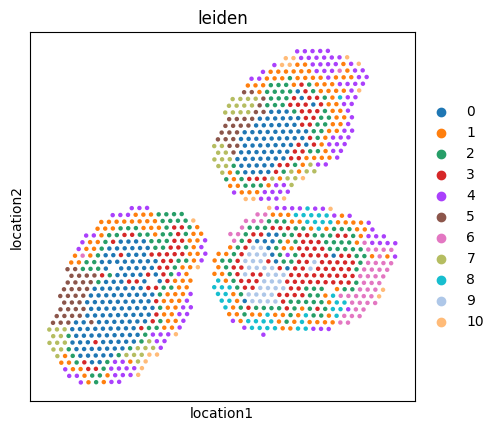

/tmp/ipykernel_451342/1511578409.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_cr, color = cluster_key_sc,spot_size = 70,)


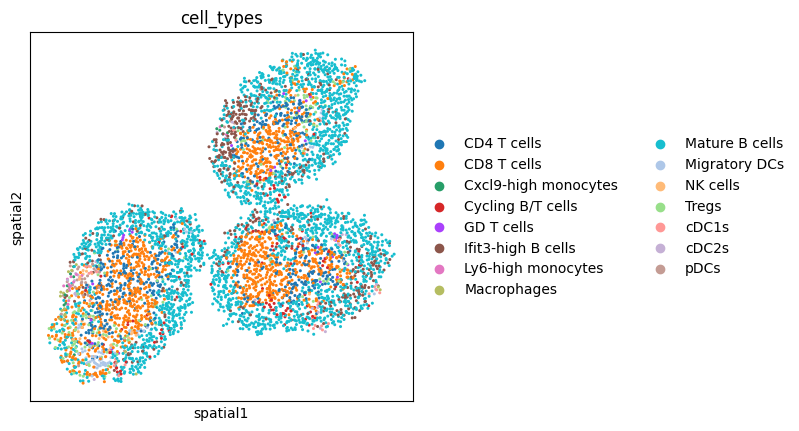

In [6]:
sc.pl.spatial(ad_st, color = cluster_key_st,spot_size=100,basis=spatial_key)
sc.pl.spatial(adata_cr, color = cluster_key_sc,spot_size = 70,)

# 4. Cell shape modeling

In [7]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = cluster_key_sc)

Simulation: 100%|██████████| 2000/2000 [04:03<00:00,  8.22it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 5460/5460 [00:51<00:00, 105.25it/s]


<Axes: >

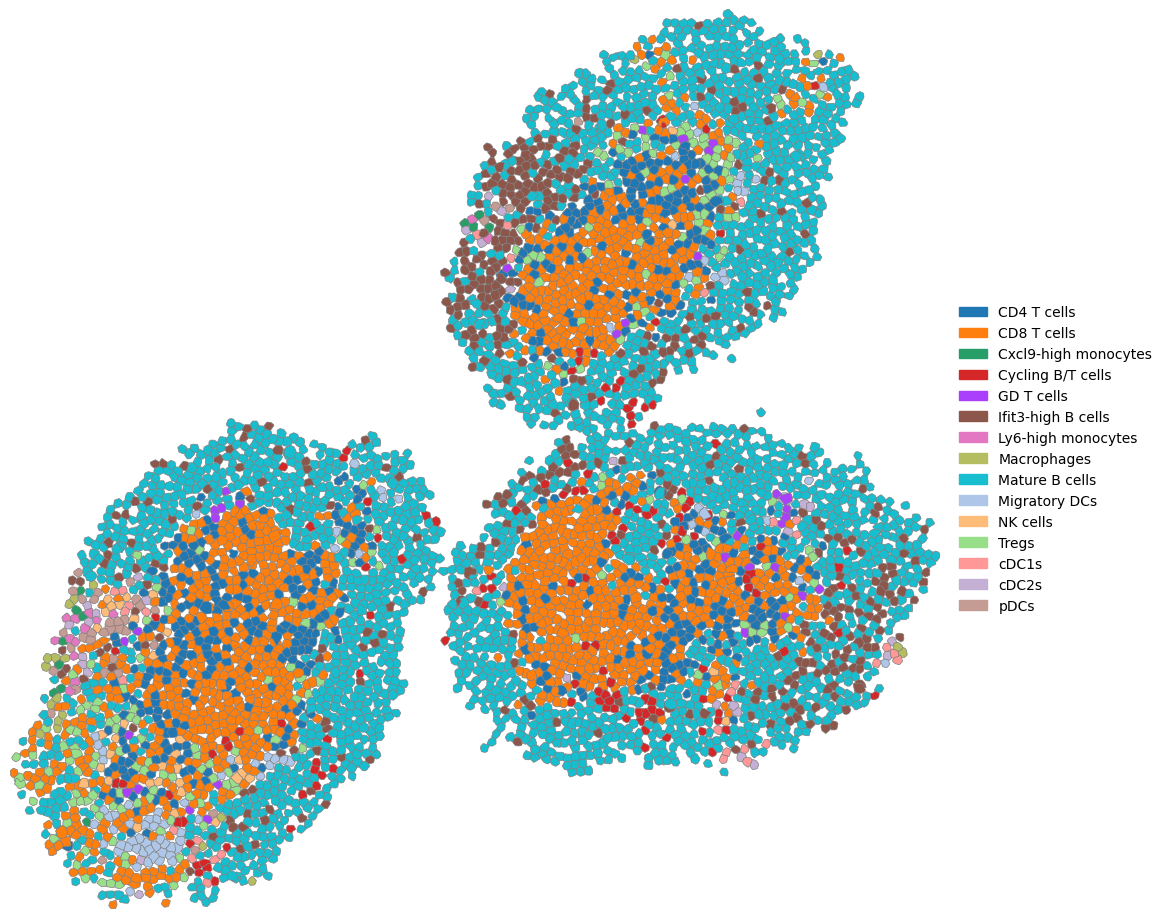

In [8]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

# 5. Contact-based communication analysis

In [ ]:
db_lr = cr.pp.ligand_receptor_database(signaling_types = 'Cell-Cell Contact')
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr, adata = adata_cr)

In [ ]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,vis_key='NOTCH',boundary_color='gray',boundary_width=0.1)
cr.pl.plot_contact_signal(sem,ax=ax,signal = 'NOTCH')

Cluster-level communication

In [ ]:
cr.tl.cluster_communication(adata_cr,cluster_key = cluster_key_sc,signal = 'NOTCH')
fig,ax=plt.subplots(figsize=(6,4))
sns.heatmap(adata_cr.uns[f'{cluster_key_sc}-NOTCH']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)

In [10]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5,save_name = 'cell_shape.png')
plt.close(fig)